In [333]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Read in CSV
df = pd.read_csv('../dataset/online_retail.csv')

# Clean Columns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Cancelled'] = df['InvoiceNo'].str.startswith('C')
df['InvoiceNo'].mask(df['Cancelled'],df['InvoiceNo'].str[1:], inplace=True)

df = df[df.StockCode.str.len() <= 6]
df['StockCode'] = df['StockCode'].str[0:5]
df = df[df.StockCode.str.isnumeric()]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Remove Damage Instances
df_qsum = df[~df.Cancelled].groupby('StockCode')['Quantity'].sum()
problem_instances = df[(df.StockCode.isin(df_qsum[df_qsum < 0].index)) & (df.Quantity < 0) & (~df.Cancelled)].index
df.drop(index=problem_instances,inplace=True)

# Separating Data
df = df[~df.Cancelled]
df_cancelled = df[df.Cancelled]


In [ ]:

# Read in CSV
df = pd.read_csv('../dataset/online_retail.csv')

# Clean Columns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Cancelled'] = df['InvoiceNo'].str.startswith('C')
df['InvoiceNo'].mask(df['Cancelled'],df['InvoiceNo'].str[1:], inplace=True)

df = df[df.StockCode.str.len() <= 6]
df['StockCode'] = df['StockCode'].str[0:5]
df = df[df.StockCode.str.isnumeric()]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Remove Damage Instances
df_qsum = df[~df.Cancelled].groupby('StockCode')['Quantity'].sum()
problem_instances = df[(df.StockCode.isin(df_qsum[df_qsum < 0].index)) & (df.Quantity < 0) & (~df.Cancelled)].index
df.drop(index=problem_instances,inplace=True)

# Separating Data
df = df[~df.Cancelled]
df_cancelled = df[df.Cancelled]


In [ ]:
# Create a Grouped Dataset
products_group = df.groupby('StockCode')[['Quantity','TotalPrice']].sum()
product_details = df.drop_duplicates('StockCode')[['StockCode','Description','UnitPrice']].set_index('StockCode')

products_group = products_group.join(product_details, on='StockCode')

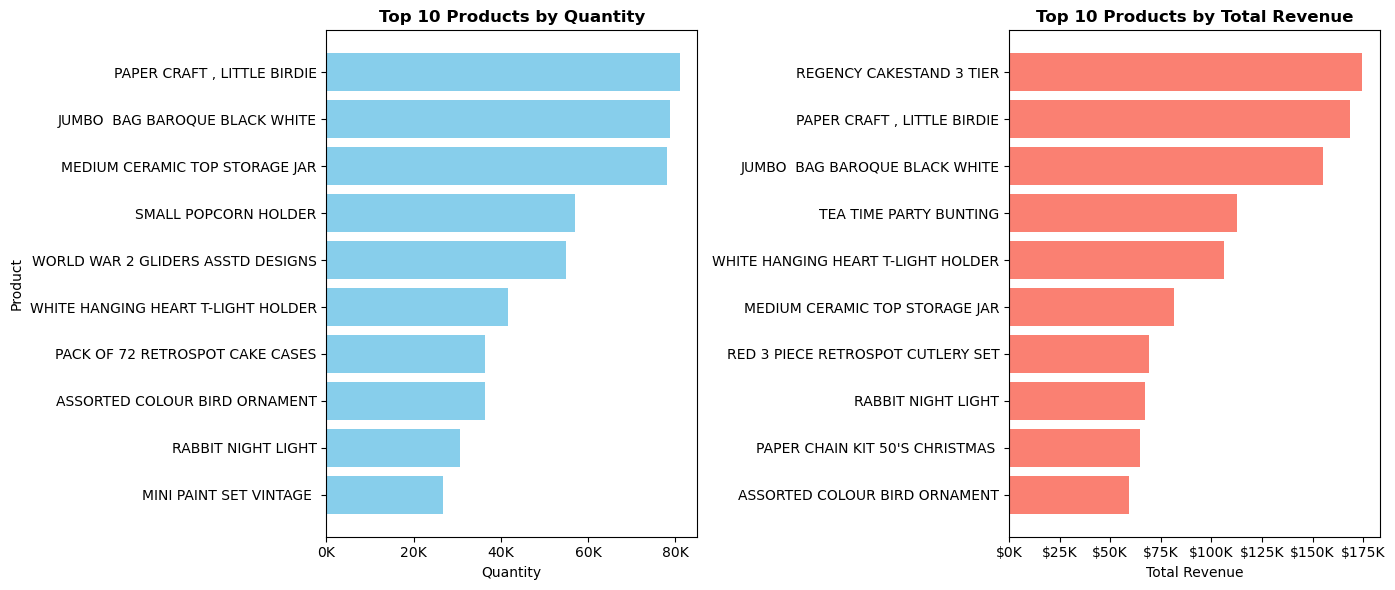

In [335]:
# Setup
top_quantity = products_group.sort_values(by='Quantity',ascending=False).head(10)
top_totalprice = products_group.sort_values(by='TotalPrice',ascending=False).head(10)

fig, ax = plt.subplots(1, 2)
fig.set_size_inches((14, 6))

# Quantity
ax[0].barh(top_quantity['Description'], top_quantity['Quantity'], color='skyblue')
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Products by Quantity', fontsize=12, weight='bold')
ax[0].set_xlabel('Quantity')
ax[0].set_ylabel('Product')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Total Price
ax[1].barh(top_totalprice['Description'], top_totalprice['TotalPrice'], color='salmon')
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Products by Total Revenue', fontsize=12, weight='bold')
ax[1].set_xlabel('Total Revenue')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Finish
plt.tight_layout()